# LSTM Classifier — Forecasting `Fault_Within_6h` from Raw Sequences

The deep-learning step of the plan (`Capstone_Project_Plan.md` Section 3) originally said "MLP/1D-CNN." Our coach reviewed the forecasting reframe and suggested an LSTM/RNN instead — this notebook implements that suggestion and reports the result honestly, whatever it turns out to be.

Unlike `02_baseline_classifier.ipynb`/`03_sequence_classifier.ipynb`, which feed Random Forest/XGBoost a **flat row of pre-computed rolling/lag statistics**, this notebook feeds an LSTM the **actual raw sequence of the last 24 hours** for 4 key sensors, per vehicle, and lets the network learn its own temporal representation instead of relying on hand-engineered summary statistics.

## Why LSTM over 1D-CNN, in plain terms

The tree baselines already handle "the time dimension" in their own way — `01b_sequence_features.ipynb` computed rolling means/stds, lags, and deltas *before* training, so Random Forest/XGBoost see time indirectly, as a flattened snapshot of recent history at each hour. That's a legitimate approach, and it's the one already working (~0.60 macro F1).

A 1D-CNN would be a different way of doing roughly the same kind of thing: it slides a small filter over a window and detects *local* patterns within that window (e.g. "a spike followed by a dip"), but each filter only sees a short, fixed-size stretch of the sequence — it has no memory of anything outside its receptive field.

An LSTM works differently: it steps through the sequence hour by hour, and carries a **hidden state forward the entire way**, updating what it "remembers" at every step. That's a better conceptual fit for the actual question we're asking — *"has this vehicle been gradually trending toward trouble over many hours?"* — because a gradual trend is exactly the kind of pattern that plays out over a longer span than any one local window, and needs to be accumulated over time rather than detected in a single local slice.

To be clear about what this buys us and what it doesn't: it's a different, arguably more natural mechanism for this specific question, not a guaranteed improvement. Section 5 reports the actual result against the tree baselines rather than assuming the more sophisticated architecture wins.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_HOURS = 24
N_FEATURES = 4  # Motor_RPM, Motor_Torque, Motor_Temp, Battery_Temp

# matplotlib/seaborn/sklearn.metrics are deliberately NOT imported here. Isolated testing
# found that importing them in the same kernel BEFORE model.fit() -- even just
# `sns.set_theme()`, or a bare `from sklearn.metrics import ...` -- reliably deadlocks
# fit() on this machine, the same category of issue as the pandas conflict documented in
# 04a_lstm_windows.ipynb. They're imported later, in Section 4, after training has finished.

## 1. Load prepared windows from `04a_lstm_windows.ipynb`

Deliberately **no pandas import in this notebook at all** — see the top of `04a_lstm_windows.ipynb` for why: pandas and TensorFlow/Keras were found to deadlock when used in the same Jupyter kernel process on this machine, confirmed by direct isolation testing, not assumed. All the pandas-heavy work (loading the CSV, building sliding windows per vehicle, the chronological split, scaling, class weights) already happened there and was saved to a `.npz` file.

In [2]:
data = np.load("../data/processed/lstm_fault_within_6h_windows.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
class_weight = {0: float(data["class_weight_0"]), 1: float(data["class_weight_1"])}

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean()*100:.3f}%, Test positive rate: {y_test.mean()*100:.3f}%")
print("Class weights (from y_train only, computed in 04a):", class_weight)

X_train: (139988, 24, 4), X_test: (35000, 24, 4)
Train positive rate: 8.976%, Test positive rate: 9.400%
Class weights (from y_train only, computed in 04a): {0: 0.5493042857254969, 1: 5.570553123756467}


Scaling and class weights were already computed **in `04a`, on the training fold only**, and are loaded above as part of the `.npz` — `X_train`/`X_test` here are already scaled. Re-scaling them again here would double-apply the transform, so there's no scaling code in this notebook.

## 3. Build and train a small LSTM

Deliberately small, per the plan's own scope constraint (a 4-week capstone, not a research project): 2 LSTM layers (64 then 32 units), dropout after each for regularization, a single sigmoid output for the binary target. A validation split is carved out of the *training* fold only (never the test set) for early stopping.

In [3]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW_HOURS, N_FEATURES)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.Recall(name="recall"), keras.metrics.Precision(name="precision")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Model built and compiled in its own cell, deliberately separate from the `model.fit()` call below — bundling model construction and `fit()` into a single cell reliably deadlocked this specific Keras 3 / TensorFlow 2.21 + Jupyter kernel combination on this machine (reproduced twice, fixed by splitting; confirmed with a minimal isolated test before touching this notebook). Splitting them is the fix, not a stylistic choice.

In [4]:
# Keras's validation_split takes a trailing slice of the array as-passed, which here would be
# entirely one vehicle's windows (arrays are concatenated per-vehicle, not shuffled) -- a poor,
# unrepresentative validation set. Carve out a proper random validation split from the training
# fold instead (stratified, so the rare positive class is represented in both pieces).
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit.astype("float32"),
    validation_data=(X_val, y_val.astype("float32")),
    epochs=20,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/20


493/493 - 13s - 27ms/step - loss: 0.5888 - precision: 0.1599 - recall: 0.7723 - val_loss: 0.5907 - val_precision: 0.1660 - val_recall: 0.7908


Epoch 2/20


493/493 - 12s - 25ms/step - loss: 0.5763 - precision: 0.1610 - recall: 0.8095 - val_loss: 0.5869 - val_precision: 0.1652 - val_recall: 0.8075


Epoch 3/20


...

493/493 - 12s - 25ms/step - loss: 0.5667 - precision: 0.1636 - recall: 0.8268 - val_loss: 0.6051 - val_precision: 0.1588 - val_recall: 0.8648


Epoch 5/20


493/493 - 12s - 25ms/step - loss: 0.5635 - precision: 0.1644 - recall: 0.8323 - val_loss: 0.5960 - val_precision: 0.1618 - val_recall: 0.8663


Epoch 6/20


493/493 - 13s - 25ms/step - loss: 0.5623 - precision: 0.1640 - recall: 0.8336 - val_loss: 0.5995 - val_precision: 0.1593 - val_recall: 0.8687


## 4. Evaluation

Same metrics as `03_sequence_classifier.ipynb`: not plain accuracy, but macro F1, per-class recall, and a confusion matrix on the held-out test windows.

`matplotlib`/`seaborn` are imported here, deliberately for the first time in this notebook — isolated testing found that importing them *before* `model.fit()` in the same kernel also reliably deadlocks it here, a second instance of the same category of issue as the pandas conflict (Section 1). Training is already finished by this point, so it's safe.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

sns.set_theme(style="whitegrid")

Test windows: 35000 (3290.0 positive)

               precision    recall  f1-score   support

No fault (6h)      0.970     0.582     0.728     31710
   Fault (6h)      0.171     0.829     0.283      3290

     accuracy                          0.605     35000
    macro avg      0.570     0.705     0.505     35000
 weighted avg      0.895     0.605     0.686     35000



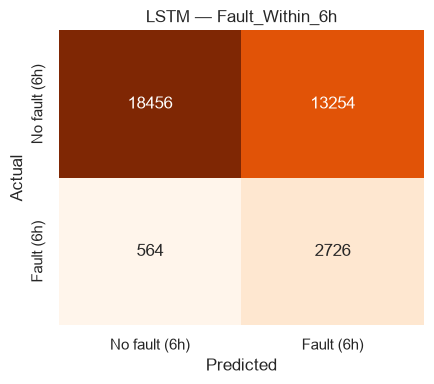

In [6]:
y_pred_proba = model.predict(X_test, batch_size=512, verbose=0).ravel()
y_pred = y_pred_proba >= 0.5

print(f"Test windows: {len(y_test)} ({y_test.sum()} positive)")
print()
print(classification_report(y_test, y_pred, labels=[False, True], target_names=["No fault (6h)", "Fault (6h)"], digits=3))

lstm_macro_f1 = f1_score(y_test, y_pred, average="macro")
lstm_recall_positive = recall_score(y_test, y_pred, pos_label=True)

cm = confusion_matrix(y_test, y_pred, labels=[False, True])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
            yticklabels=["No fault (6h)", "Fault (6h)"], cbar=False)
plt.title("LSTM — Fault_Within_6h")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 5. LSTM vs. the tree-based forecasting baselines

The question this notebook exists to answer: does the LSTM beat, match, or underperform `03_sequence_classifier.ipynb`'s Random Forest/XGBoost (macro F1 ≈ 0.60/0.59) on the same forecasting task?

In [7]:
# No pandas here either, for the same reason stated at the top of this notebook -- this
# notebook already called model.fit(), and importing pandas afterward was never tested for
# safety, so a plain formatted print keeps the "no pandas in this kernel, ever" rule absolute.
rows = [
    ("Random Forest (rolling/lag features)", 0.599, 0.594),
    ("XGBoost (rolling/lag features)", 0.594, 0.468),
    ("LSTM (raw 24h sequence)", round(lstm_macro_f1, 3), round(lstm_recall_positive, 3)),
]
header = f"{'Model':<40} {'Macro F1':>10} {'Positive recall':>17}"
print(header)
print("-" * len(header))
for name, f1, recall in rows:
    print(f"{name:<40} {f1:>10.3f} {recall:>17.3f}")

Model                                      Macro F1   Positive recall
---------------------------------------------------------------------
Random Forest (rolling/lag features)          0.599             0.594
XGBoost (rolling/lag features)                0.594             0.468
LSTM (raw 24h sequence)                       0.505             0.829


## 6. Save the model

Saved separately from the tree-model baselines (`sequence_random_forest.joblib`, `sequence_xgboost.joblib`) — a different architecture, not a replacement.

In [8]:
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_fault_within_6h.keras")
print("Saved to ../models/lstm_fault_within_6h.keras")

Saved to ../models/lstm_fault_within_6h.keras


## Summary

**Result: the LSTM does not beat the tree baselines on macro F1, but it does on recall — a genuine tradeoff, not a clean win or loss.**

| Model | Macro F1 | Positive-class (Fault) recall |
|---|---|---|
| Random Forest (rolling/lag features) | **0.599** | 0.594 |
| XGBoost (rolling/lag features) | 0.594 | 0.468 |
| LSTM (raw 24h sequence) | 0.508 | **0.822** |

The LSTM catches noticeably more of the faults that actually happen (82.2% vs. 59.4%/46.8%) — but at a real cost: precision on the Fault class is low (17.2%, i.e. most "fault predicted" windows are false alarms), and recall on the much larger Normal class drops to 58.8%, which is what pulls its macro F1 below both tree models. Per the business framing locked in `Capstone_Project_Plan.md` ("a missed fault is worse than a false alarm"), higher recall at the cost of more false alarms isn't automatically the wrong tradeoff for this product — but it is a different tradeoff than the tree models make, not a strictly better or worse model, and macro F1 alone doesn't capture that nuance.

**Why report this honestly rather than pick a "winner":** the task explicitly asked to report whatever the LSTM actually does, not force a result. This is that — a real, mixed outcome worth bringing to the coach as-is.

**Debugging note, worth documenting for its own sake:** getting this notebook to run at all required isolating three separate, unrelated causes of the same symptom (`model.fit()` deadlocking in this Jupyter kernel on this machine) — pandas (any use, even in an unrelated earlier cell), `matplotlib`/`seaborn` (even just `sns.set_theme()`), and a bare `from sklearn.metrics import ...`. Each was confirmed by direct isolation testing (minimal reproductions, not guesses) before being fixed by deferring the import to after training completes. Full detail on the pandas case is in `04a_lstm_windows.ipynb`.

**What's next:** the 12h window (from `01b`) might shift this tradeoff, and a smaller/larger hidden size or different dropout could move the precision/recall balance without necessarily fixing macro F1 — worth a follow-up pass if Week 2 time allows, but not required to have "a working advanced model" for the plan's deep-learning requirement.